<a href="https://www.kaggle.com/code/nikita2901699/practical-nn?scriptVersionId=294618299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [3]:
dataset0 = datasets.ImageFolder(data_dir)

In [4]:
len(dataset0)

3527

In [5]:
img, label = dataset0[3526]

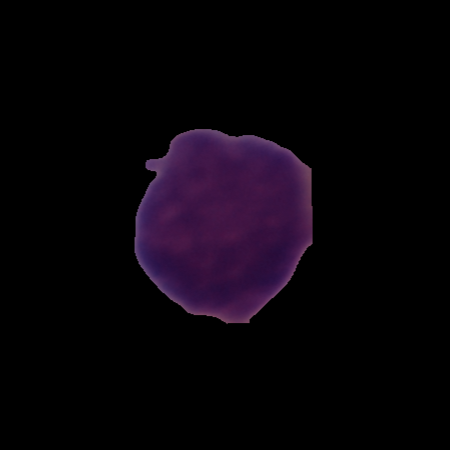

In [6]:
img

In [7]:
dataset0.classes

['all', 'hem']

In [8]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [9]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [10]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [11]:
len(dataset_all)

10661

In [12]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [13]:
len(data_train)


8529

In [14]:
len(data_test)


2132

In [15]:
img, label = data_train[5000]

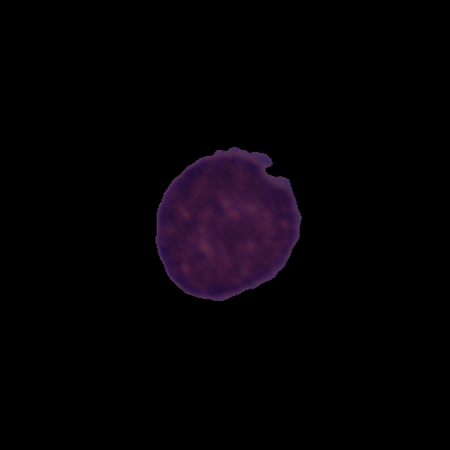

In [16]:
img

In [17]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [18]:
train_transform(img).shape

torch.Size([3, 180, 180])

In [19]:
test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.ToTensor()
    ]
)

In [20]:
test_transform(img).shape

torch.Size([3, 180, 180])

In [21]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [22]:
train_data = TransformDataset(data_train,train_transform)

In [23]:
test_data = TransformDataset(data_test,test_transform)

In [24]:
len(test_data)

2132

In [25]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 1)

In [26]:
train_loader = DataLoader(train_data, batch_size=256)

In [27]:
test_loader = DataLoader(test_data, batch_size=256)


In [28]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([84, 3, 180, 180])
torch.Size([84])


(180, 180, 3)


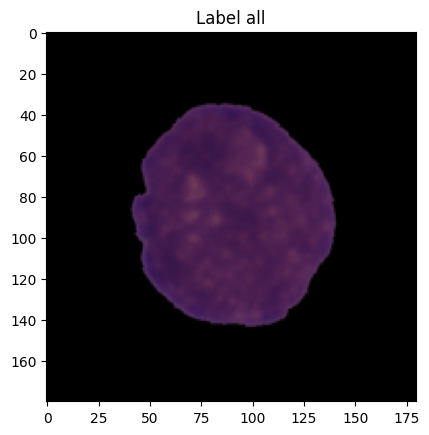

(180, 180, 3)


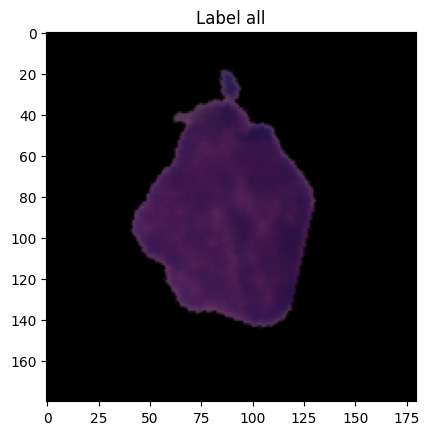

(180, 180, 3)


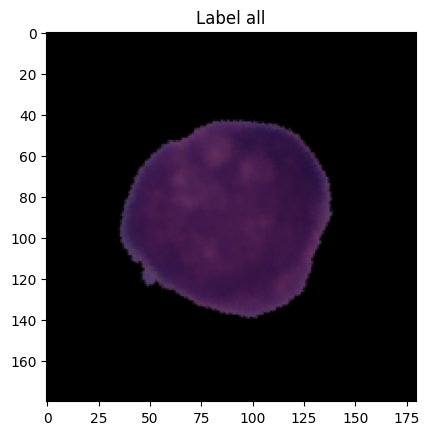

In [29]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

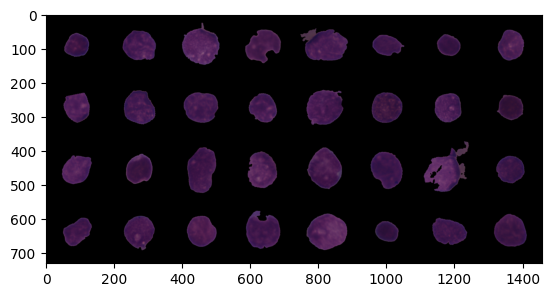

In [30]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [31]:
3*60*60

10800

In [32]:
# from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(10800, 64),
#     nn.ReLU(),
#     nn.Linear(64, 32),
#     nn.ReLU(),
#     nn.Linear(32, 16),
#     nn.ReLU(),
#     nn.Linear(16, 2)
# )

# device = "cuda"
# model = model.to(device)

from torch import nn

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),# розмір буде 8,180,180
    nn.ReLU(),
    nn.MaxPool2d(2,2), #8, 90 , 90
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),#16, 90, 90
    nn.ReLU(), # 16, 90, 90
    nn.MaxPool2d(2, 2), # 16, 45, 45
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), #32, 45, 45
    nn.ReLU(), #32, 45, 45
    nn.MaxPool2d(2, 2), # 32, 22, 22

    nn.Flatten(), # 32*22*22 - 15488
    nn.Linear(15488, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = 'cuda'
model = model.to(device)

In [33]:
32*22*22

15488

In [34]:
for imgs, labels in train_loader:
    break

In [35]:
imgs.shape

torch.Size([256, 3, 180, 180])

In [38]:
res = model(imgs)
res.shape

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [40]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss


loss: 0.7168999910354614
loss: 0.6742503643035889
loss: 0.6378398537635803
loss: 0.6277872920036316
loss: 0.6802878975868225
loss: 0.6353489756584167
loss: 0.597375750541687
loss: 0.6305869221687317
loss: 0.620894193649292
loss: 0.632310152053833
loss: 0.6156762838363647
loss: 0.6027057766914368
loss: 0.611791729927063
loss: 0.5905488729476929
loss: 0.6323898434638977
loss: 0.5851980447769165
loss: 0.5819764733314514
loss: 0.5869706869125366
loss: 0.5899233818054199
loss: 0.586729884147644
loss: 0.5833674669265747
loss: 0.5988790392875671
loss: 0.5671485662460327
loss: 0.5655115246772766
loss: 0.5320104956626892
loss: 0.5501189231872559
loss: 0.5271814465522766
loss: 0.5016364455223083
loss: 0.5196326971054077
loss: 0.496523916721344
loss: 0.5007924437522888
loss: 0.5101690292358398
loss: 0.4695075750350952
loss: 0.4672863483428955
loss: 0.46593499183654785
loss: 0.5436859130859375
loss: 0.5244218111038208
loss: 0.4732649326324463
loss: 0.6189650297164917
loss: 0.5242971777915955
loss:

In [41]:
imgs.shape 

torch.Size([81, 3, 180, 180])

In [51]:
image = torch.rand(1, 3, 180, 180)
image 

tensor([[[[0.2447, 0.4961, 0.7422,  ..., 0.6642, 0.5020, 0.2843],
          [0.2739, 0.5822, 0.4117,  ..., 0.0166, 0.3612, 0.4473],
          [0.9406, 0.3265, 0.4174,  ..., 0.7030, 0.9955, 0.9006],
          ...,
          [0.0946, 0.2541, 0.7044,  ..., 0.4885, 0.3375, 0.5280],
          [0.2361, 0.7451, 0.1683,  ..., 0.0452, 0.3182, 0.7522],
          [0.5249, 0.8829, 0.8480,  ..., 0.1329, 0.5196, 0.5924]],

         [[0.5327, 0.4113, 0.3856,  ..., 0.3272, 0.7144, 0.8921],
          [0.5076, 0.5221, 0.6621,  ..., 0.7689, 0.0169, 0.5407],
          [0.0997, 0.0330, 0.4488,  ..., 0.5971, 0.4227, 0.5637],
          ...,
          [0.5307, 0.7256, 0.0136,  ..., 0.8174, 0.1964, 0.2886],
          [0.0723, 0.7852, 0.9234,  ..., 0.0453, 0.2725, 0.7968],
          [0.7178, 0.8577, 0.7629,  ..., 0.4861, 0.7505, 0.9601]],

         [[0.9600, 0.5196, 0.8432,  ..., 0.7322, 0.2505, 0.4571],
          [0.8218, 0.1339, 0.3689,  ..., 0.8092, 0.9099, 0.2238],
          [0.0944, 0.8537, 0.7556,  ..., 0

In [52]:
model = model.to('cpu')
torch.onnx.export(
    model,
    image,
    'leukemia.onnx',
    input_names = ["input"],
    output_names = ["output"]
)

/tmp/ipykernel_55/730945670.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [ ]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)



In [ ]:
plt.plot(loss_test_list)

In [ ]:
imgs.shape

In [ ]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

In [ ]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

In [ ]:
result = model(imgs)

In [ ]:
res1 = result.argmax(dim=1)

In [ ]:
labels

In [ ]:
res2 = res1 == labels

In [ ]:
res2.sum()

In [ ]:
67/81

In [ ]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

In [ ]:
len(train_data) 

In [ ]:
6829/8529